PART A — DATASET PREPARATION

In [4]:
# 24BAD090 - PART A

import numpy as np
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

dataset = load_dataset("karpathy/tiny_shakespeare")

print(dataset)
print(dataset["train"][0]["text"][:500])

train_text = dataset["train"][0]["text"].lower()

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([train_text])

total_words = min(10000, len(tokenizer.word_index) + 1)

token_list = tokenizer.texts_to_sequences([train_text])[0]

max_sequence_length = 20

sequences = []

for i in range(1, len(token_list)):
    start = max(0, i - max_sequence_length + 1)
    sequences.append(token_list[start:i+1])

sequences = pad_sequences(
    sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

X = sequences[:, :-1]
y = sequences[:, -1]

split = int(0.9 * len(X))

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

print("Vocabulary:", total_words)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 1
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 1
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1
    })
})
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor
Vocabulary: 10000
X_train: (165394, 19)
y_train: (165394,)
X_val: (18378, 19)
y_val: (18378,)


PART B — RNN MODEL

In [5]:
# 24BAD090 - PART B

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

PART C — TRAINING AND GRAPHS

Epoch 1/5
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 127s 96ms/step - accuracy: 0.0394 - loss: 6.7883 - val_accuracy: 0.0627 - val_loss: 6.3888
Epoch 2/5
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 112s 87ms/step - accuracy: 0.0752 - loss: 6.1546 - val_accuracy: 0.0804 - val_loss: 6.1764
Epoch 3/5
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 138s 84ms/step - accuracy: 0.0918 - loss: 5.8296 - val_accuracy: 0.0867 - val_loss: 6.1016
Epoch 4/5
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 109s 85ms/step - accuracy: 0.1039 - loss: 5.5661 - val_accuracy: 0.0883 - val_loss: 6.1144
Epoch 5/5
1293/1293 ━━━━━━━━━━━━━━━━━━━━ 141s 84ms/step - accuracy: 0.1133 - loss: 5.3269 - val_accuracy: 0.0913 - val_loss: 6.1559
Epoch 1: Train Acc=0.0394, Val Acc=0.0627, Train Loss=6.7883, Val Loss=6.3888
Epoch 2: Train Acc=0.0752, Val Acc=0.0804, Train Loss=6.1546, Val Loss=6.1764
Epoch 3: Train Acc=0.0918, Val Acc=0.0867, Train Loss=5.8296, Val Loss=6.1016
Epoch 4: Train Acc=0.1039, Val Acc=0.0883, Train Loss=5.5661, Val Loss=6.1144
Epoch 5: Train Acc=0.1133, V

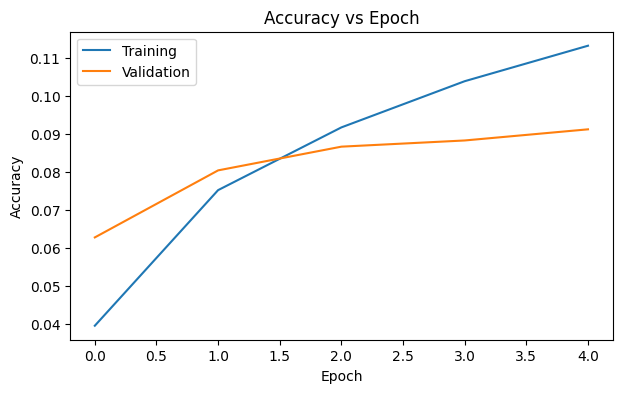

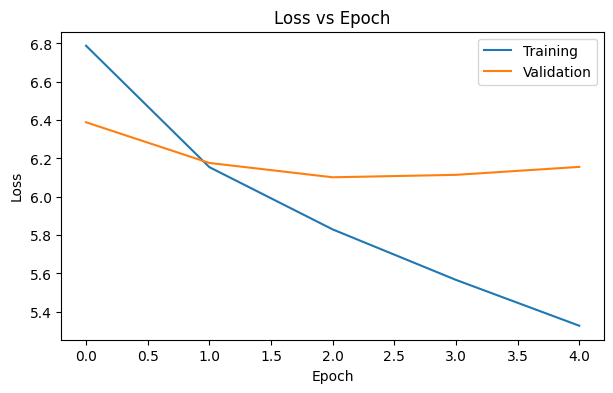

In [6]:
# 24BAD090 - PART C

import matplotlib.pyplot as plt

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=128
)

for i in range(5):
    print(
        f"Epoch {i+1}: "
        f"Train Acc={history.history['accuracy'][i]:.4f}, "
        f"Val Acc={history.history['val_accuracy'][i]:.4f}, "
        f"Train Loss={history.history['loss'][i]:.4f}, "
        f"Val Loss={history.history['val_loss'][i]:.4f}"
    )

plt.figure(figsize=(7,4))
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.show()

plt.figure(figsize=(7,4))
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

PART D — TEXT GENERATION

In [7]:
# 24BAD090 - PART D

from tensorflow.keras.preprocessing.sequence import pad_sequences

index_to_word = {
    i: w for w, i in tokenizer.word_index.items()
}

def generate_text(seed, n=20):
    text = seed.lower()

    for _ in range(n):
        seq = tokenizer.texts_to_sequences([text])[0]
        seq = seq[-19:]
        seq = pad_sequences([seq], maxlen=19, padding="pre")

        pred = model.predict(seq, verbose=0)
        word_id = np.argmax(pred[0])

        word = index_to_word.get(word_id)

        if word is None:
            break

        text += " " + word

    return text


seeds = [
    "the king",
    "my lord",
    "thou art",
    "good night",
    "what is"
]

for seed in seeds:
    print("\nSeed:", seed)
    print(generate_text(seed, 20))

model.save("24BAD090_tiny_shakespeare_rnn.keras")


Seed: the king
the king henry vi the king is dead and i am a man and yet i am a man to be a

Seed: my lord
my lord king richard iii why then thou art thou art not to be a man and <OOV> of the <OOV> of

Seed: thou art
thou art not to be a man and in the world i am a man to be a <OOV> of a <OOV>

Seed: good night
good night and i will be a man to be a <OOV> of a <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV> <OOV>

Seed: what is
what is the king henry bolingbroke i am a man to be a man and in the world i am a man
